In [1]:
!git clone https://github.com/ethicalcod/neuroBrain.git
%cd neuroBrain

Cloning into 'neuroBrain'...
remote: Enumerating objects: 107, done.
remote: Counting objects: 100% (107/107), done.
remote: Compressing objects: 100% (90/90), done.
remote: Total 107 (delta 48), reused 43 (delta 12), pack-reused 0 (from 0)
Receiving objects: 100% (107/107), 1.06 MiB | 14.89 MiB/s, done.
Resolving deltas: 100% (48/48), done.
/content/neuroBrain


In [3]:
!python scripts/setup_project.py

NeuroBrain Project Setup
Checking project structure...
docs Exists!
figures Exists!
models Exists!
notebooks Exists!
results Exists!
scripts Exists!
src Exists!
Installing Python packages...
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Failed to retrieve file url:

	Too many users have viewed or downloaded this file recently. Please
	try accessing the file again later. If the file you are trying to
	access is particularly large or is shared with many people, it may
	take up to 24 hours to be able to view or download the file. If you
	still can't access a file after 24 hours, contact your domain
	administrator.

You may still be able to access the file from the browser:

	https://drive.google.com/uc?id=1A2IU8Sgea1h3fYLpYtFb2v7NYdMjvEhU

but Gdown can't. Please check connections and permissions.
Traceback (most rec

In [58]:
%%writefile src/config.py

"""
NeuroBrain Project Configuration

This module centralizes project paths and global configuration.
"""

from pathlib import Path

# Project Paths

PROJECT_ROOT = Path(__file__).resolve().parent.parent

SRC_DIR = PROJECT_ROOT / "src"
SCRIPTS_DIR = PROJECT_ROOT / "scripts"
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
FIGURES_DIR = PROJECT_ROOT / "figures"
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"
DOCS_DIR = PROJECT_ROOT / "docs"

# Dataset

DATASET_NAME = "Task01_BrainTumour"

DATASET_FILE_ID = "1A2IU8Sgea1h3fYLpYtFb2v7NYdMjvEhU"

ARCHIVE_NAME = "Task01_BrainTumour.tar"

DATASET_ROOT = PROJECT_ROOT / DATASET_NAME

IMAGES_PATH = DATASET_ROOT / "imagesTr"
LABELS_PATH = DATASET_ROOT / "labelsTr"
TEST_IMAGES_PATH = DATASET_ROOT / "imagesTs"

DATASET_JSON = DATASET_ROOT / "dataset.json"

RANDOM_SEED = 42

# Training Placeholders

BATCH_SIZE = 2
NUM_WORKERS = 2

# Visualization

FIGURE_DPI = 300

Overwriting src/config.py


In [5]:
!python scripts/setup_project.py

NeuroBrain Project Setup
Checking project structure...
docs Exists!
figures Exists!
models Exists!
notebooks Exists!
results Exists!
scripts Exists!
src Exists!
Installing Python packages...
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=17kUAGnj5OhVj8yrAOae6a37jT10R01eX
From (redirected): https://drive.google.com/uc?id=17kUAGnj5OhVj8yrAOae6a37jT10R01eX&confirm=t&uuid=4aa80e2a-7ec0-4f8c-933e-ead1ca0c6969
To: /content/neuroBrain/Task01_BrainTumour.tar
100% 7.61G/7.61G [01:24<00:00, 90.3MB/s]
Download complete.
Extracting archive...
/content/neuroBrain/scripts/setup_dataset.py:65: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  ta

In [6]:
import monai

print(monai.__version__)

1.6.0


In [7]:
import importlib
import src.loaders

importlib.reload(src.loaders)

train_loader, val_loader = src.loaders.create_dataloaders()

batch = next(iter(train_loader))

print(batch["image"].shape)
print(batch["label"].shape)

Images : 484
Labels : 484
Dataset verification passed.
torch.Size([2, 4, 240, 240, 155])
torch.Size([2, 240, 240, 155])


In [8]:
%%writefile src/transforms.py

"""
MONAI transform pipelines for NeuroBrain.
"""

from monai.transforms import (
    Compose,
    EnsureTyped,
    NormalizeIntensityd,
)


def get_train_transforms():
    """
    Training transform pipeline.
    """

    return Compose(
        [
            NormalizeIntensityd(
                keys="image",
                nonzero=True,
                channel_wise=True,
            ),

            EnsureTyped(
                keys=["image", "label"],
            ),
        ]
    )


def get_val_transforms():
    """
    Validation transform pipeline.
    """

    return Compose(
        [
            NormalizeIntensityd(
                keys="image",
                nonzero=True,
                channel_wise=True,
            ),

            EnsureTyped(
                keys=["image", "label"],
            ),
        ]
    )

Overwriting src/transforms.py


In [9]:
import importlib
import src.transforms

importlib.reload(src.transforms)

from src.transforms import get_train_transforms

print(get_train_transforms().transforms)

(<monai.transforms.intensity.dictionary.NormalizeIntensityd object at 0x7cf135bf7e00>, <monai.transforms.utility.dictionary.EnsureTyped object at 0x7cf13584a930>)


In [10]:
import importlib
import src.loaders

importlib.reload(src.loaders)

train_loader, _ = src.loaders.create_dataloaders()

batch = next(iter(train_loader))

print(batch["image"].shape)
print(batch["image"].dtype)

print(batch["label"].shape)
print(batch["label"].dtype)

Images : 484
Labels : 484
Dataset verification passed.
torch.Size([2, 4, 240, 240, 155])
torch.float32
torch.Size([2, 240, 240, 155])
torch.int64


In [13]:
# Verify the transform pipeline
import importlib
import src.transforms

importlib.reload(src.transforms)

from src.transforms import get_train_transforms

print(get_train_transforms().transforms)

(<monai.transforms.intensity.dictionary.NormalizeIntensityd object at 0x7cf1fc6eeab0>, <monai.transforms.utility.dictionary.EnsureTyped object at 0x7cf1353b81d0>)


In [14]:
# Verify the DataLoader
import importlib
import src.loaders

importlib.reload(src.loaders)

train_loader, val_loader = src.loaders.create_dataloaders()

batch = next(iter(train_loader))

print("Image shape :", batch["image"].shape)
print("Label shape :", batch["label"].shape)

print("Image dtype :", batch["image"].dtype)
print("Label dtype :", batch["label"].dtype)

print("Image min :", batch["image"].min().item())
print("Image max :", batch["image"].max().item())
print("Image mean:", batch["image"].mean().item())
print("Image std :", batch["image"].std().item())

Images : 484
Labels : 484
Dataset verification passed.
Image shape : torch.Size([2, 4, 240, 240, 155])
Label shape : torch.Size([2, 240, 240, 155])
Image dtype : torch.float32
Label dtype : torch.int64
Image min : -3.811260223388672
Image max : 13.004311561584473
Image mean: 1.3459112990776845e-10
Image std : 0.38749605417251587


In [15]:
%%writefile src/transforms.py

from monai.transforms import (
    Compose,
    EnsureTyped,
    NormalizeIntensityd,
    RandFlipd,
)


def get_train_transforms():
    return Compose([
        NormalizeIntensityd(
            keys="image",
            nonzero=True,
            channel_wise=True,
        ),

        RandFlipd(
            keys=["image", "label"],
            prob=0.5,
            spatial_axis=0,
        ),

        EnsureTyped(
            keys=["image", "label"],
        ),
    ])


def get_val_transforms():
    return Compose([
        NormalizeIntensityd(
            keys="image",
            nonzero=True,
            channel_wise=True,
        ),

        EnsureTyped(
            keys=["image", "label"],
        ),
    ])

Overwriting src/transforms.py


In [17]:
import importlib
import src.loaders

importlib.reload(src.loaders)

train_loader, val_loader = src.loaders.create_dataloaders()

batch = next(iter(train_loader))

print("Image shape :", batch["image"].shape)
print("Label shape :", batch["label"].shape)

print("Image dtype :", batch["image"].dtype)
print("Label dtype :", batch["label"].dtype)

print("Image min :", batch["image"].min().item())
print("Image max :", batch["image"].max().item())
print("Image mean:", batch["image"].mean().item())
print("Image std :", batch["image"].std().item())

Images : 484
Labels : 484
Dataset verification passed.
Image shape : torch.Size([2, 4, 240, 240, 155])
Label shape : torch.Size([2, 240, 240, 155])
Image dtype : torch.float32
Label dtype : torch.int64
Image min : -3.991861343383789
Image max : 16.996402740478516
Image mean: 1.316002168350039e-10
Image std : 0.4187588691711426


In [20]:
%%writefile src/transforms.py

from monai.transforms import (
    Compose,
    EnsureTyped,
    NormalizeIntensityd,
    RandFlipd,

)


def get_train_transforms():
    """
    Training transform pipeline.
    """

    return Compose(
        [
            NormalizeIntensityd(
                keys="image",
                nonzero=True,
                channel_wise=True,
            ),

            RandFlipd(
                keys=["image", "label"],
                prob=0.5,
                spatial_axis=0,
            ),

            EnsureTyped(
                keys=["image", "label"],
            ),
        ]
    )

def get_val_transforms():
    return Compose([
        NormalizeIntensityd(
            keys="image",
            nonzero=True,
            channel_wise=True,
        ),

        EnsureTyped(
            keys=["image", "label"],
        ),
    ])

Overwriting src/transforms.py


In [21]:
import importlib
import src.transforms
import src.loaders

importlib.reload(src.transforms)
importlib.reload(src.loaders)

train_loader, val_loader = src.loaders.create_dataloaders()

batch = next(iter(train_loader))

print("Image shape :", batch["image"].shape)
print("Label shape :", batch["label"].shape)

print("Image dtype :", batch["image"].dtype)
print("Label dtype :", batch["label"].dtype)

Images : 484
Labels : 484
Dataset verification passed.
Image shape : torch.Size([2, 4, 240, 240, 155])
Label shape : torch.Size([2, 240, 240, 155])
Image dtype : torch.float32
Label dtype : torch.int64


In [23]:
%%writefile src/visualization.py

"""
Visualization utilities for NeuroBrain.
"""

import matplotlib.pyplot as plt


def show_sample(sample, slice_index=77):
    """
    Display one MRI slice and its segmentation mask.

    Parameters
    ----------
    sample : dict
        Sample returned by BrainTumourDataset.

    slice_index : int
        Axial slice to display.
    """

    image = sample["image"][0]      # FLAIR modality
    label = sample["label"]

    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(image[:, :, slice_index], cmap="gray")
    plt.title("FLAIR")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(label[:, :, slice_index], cmap="viridis")
    plt.title("Segmentation")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

Overwriting src/visualization.py


Images : 484
Labels : 484
Dataset verification passed.


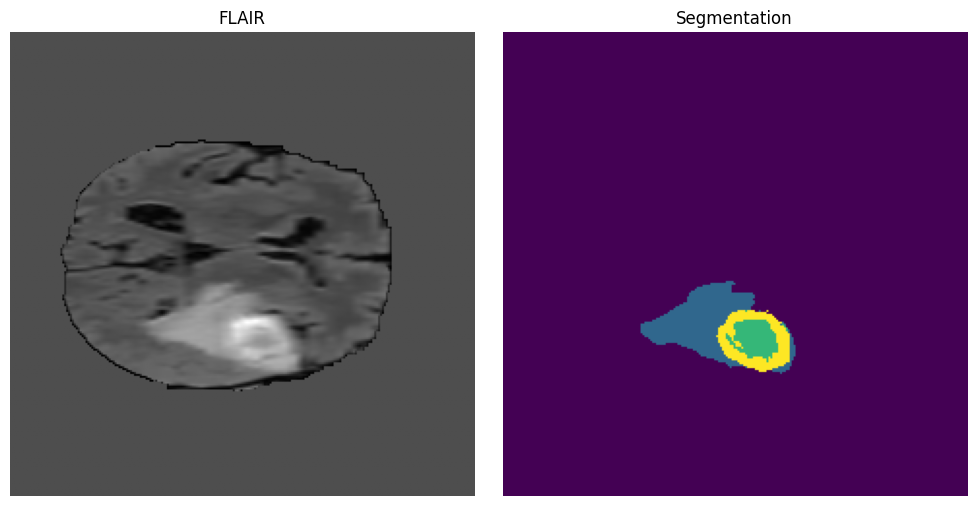

In [24]:
import importlib

import src.visualization
import src.dataloader

importlib.reload(src.visualization)
importlib.reload(src.dataloader)

from src.dataloader import BrainTumourDataset
from src.transforms import get_train_transforms
from src.visualization import show_sample

dataset = BrainTumourDataset(
    transform=get_train_transforms()
)

sample = dataset[0]

show_sample(sample)

In [26]:
%%writefile src/visualization.py

"""
Visualization utilities for NeuroBrain.
"""

import matplotlib.pyplot as plt


def compare_samples(original, augmented, slice_index=77):
    """
    Compare original and augmented MRI slices.

    Parameters
    ----------
    original : dict
        Original dataset sample.

    augmented : dict
        Augmented dataset sample.

    slice_index : int
        Axial slice index.
    """

    fig, axes = plt.subplots(2, 2, figsize=(10, 10))

    # Original MRI
    axes[0, 0].imshow(original["image"][0][:, :, slice_index], cmap="gray")
    axes[0, 0].set_title("Original FLAIR")
    axes[0, 0].axis("off")

    # Original Mask
    axes[0, 1].imshow(original["label"][:, :, slice_index], cmap="viridis")
    axes[0, 1].set_title("Original Mask")
    axes[0, 1].axis("off")

    # Augmented MRI
    axes[1, 0].imshow(augmented["image"][0][:, :, slice_index], cmap="gray")
    axes[1, 0].set_title("Augmented FLAIR")
    axes[1, 0].axis("off")

    # Augmented Mask
    axes[1, 1].imshow(augmented["label"][:, :, slice_index], cmap="viridis")
    axes[1, 1].set_title("Augmented Mask")
    axes[1, 1].axis("off")

    plt.tight_layout()
    plt.show()

Overwriting src/visualization.py


Images : 484
Labels : 484
Dataset verification passed.
Images : 484
Labels : 484
Dataset verification passed.


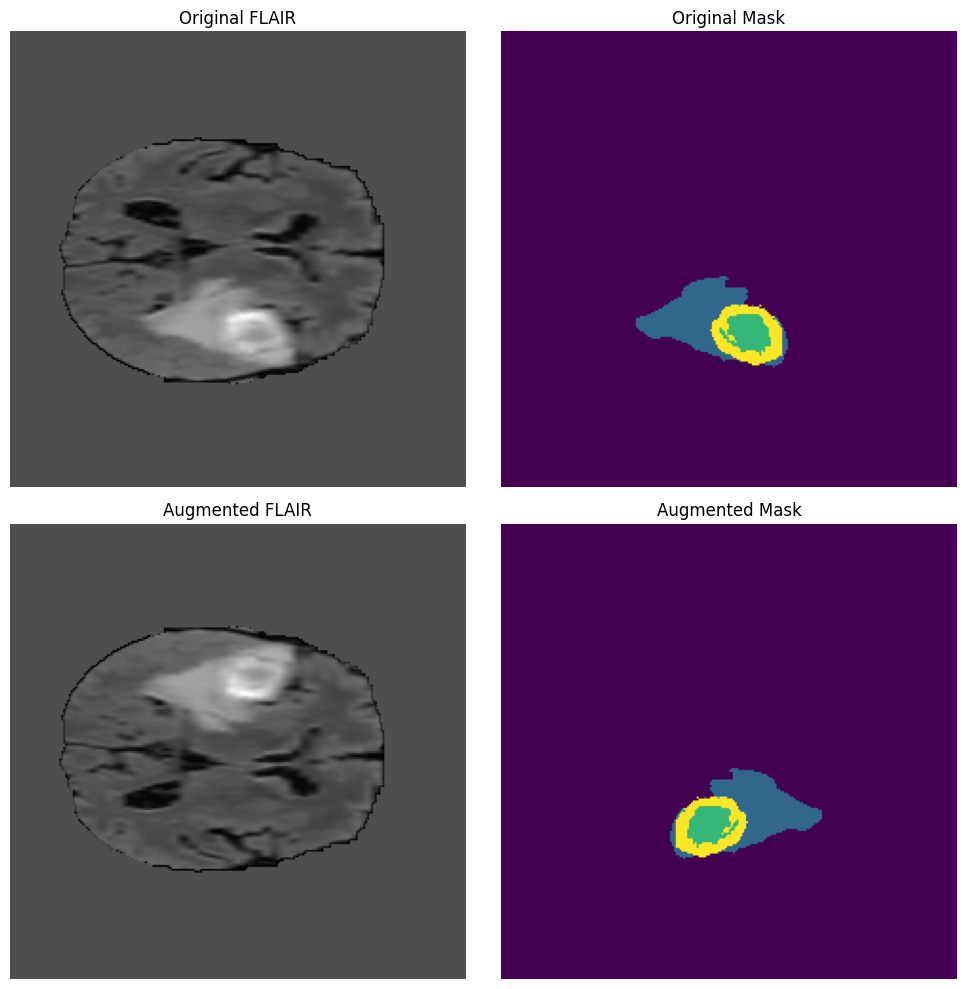

In [27]:
# Test Augmentation
import importlib

import src.visualization
import src.dataloader

importlib.reload(src.visualization)
importlib.reload(src.dataloader)

from src.dataloader import BrainTumourDataset
from src.transforms import get_train_transforms
from src.visualization import compare_samples

# Dataset without augmentation
original_dataset = BrainTumourDataset()

# Dataset with augmentation
augmented_dataset = BrainTumourDataset(
    transform=get_train_transforms()
)

original = original_dataset[0]
augmented = augmented_dataset[0]

compare_samples(original, augmented)

In [28]:
%%writefile src/visualization.py

"""
Visualization utilities for NeuroBrain.
"""

import matplotlib.pyplot as plt


def compare_samples(original, augmented, slice_index=77):
    """
    Compare original and augmented MRI with segmentation overlay.
    """

    fig, axes = plt.subplots(2, 2, figsize=(12, 12))

    # Original MRI

    axes[0, 0].imshow(
        original["image"][0][:, :, slice_index],
        cmap="gray",
    )
    axes[0, 0].set_title("Original MRI")
    axes[0, 0].axis("off")

    # Original Overlay

    axes[0, 1].imshow(
        original["image"][0][:, :, slice_index],
        cmap="gray",
    )

    axes[0, 1].imshow(
        original["label"][:, :, slice_index],
        cmap="jet",
        alpha=0.45,
    )

    axes[0, 1].set_title("Original Overlay")
    axes[0, 1].axis("off")

    # Augmented MRI

    axes[1, 0].imshow(
        augmented["image"][0][:, :, slice_index],
        cmap="gray",
    )

    axes[1, 0].set_title("Augmented MRI")
    axes[1, 0].axis("off")

    # Augmented Overlay

    axes[1, 1].imshow(
        augmented["image"][0][:, :, slice_index],
        cmap="gray",
    )

    axes[1, 1].imshow(
        augmented["label"][:, :, slice_index],
        cmap="jet",
        alpha=0.45,
    )

    axes[1, 1].set_title("Augmented Overlay")
    axes[1, 1].axis("off")

    plt.tight_layout()
    plt.show()

Overwriting src/visualization.py


Images : 484
Labels : 484
Dataset verification passed.
Images : 484
Labels : 484
Dataset verification passed.


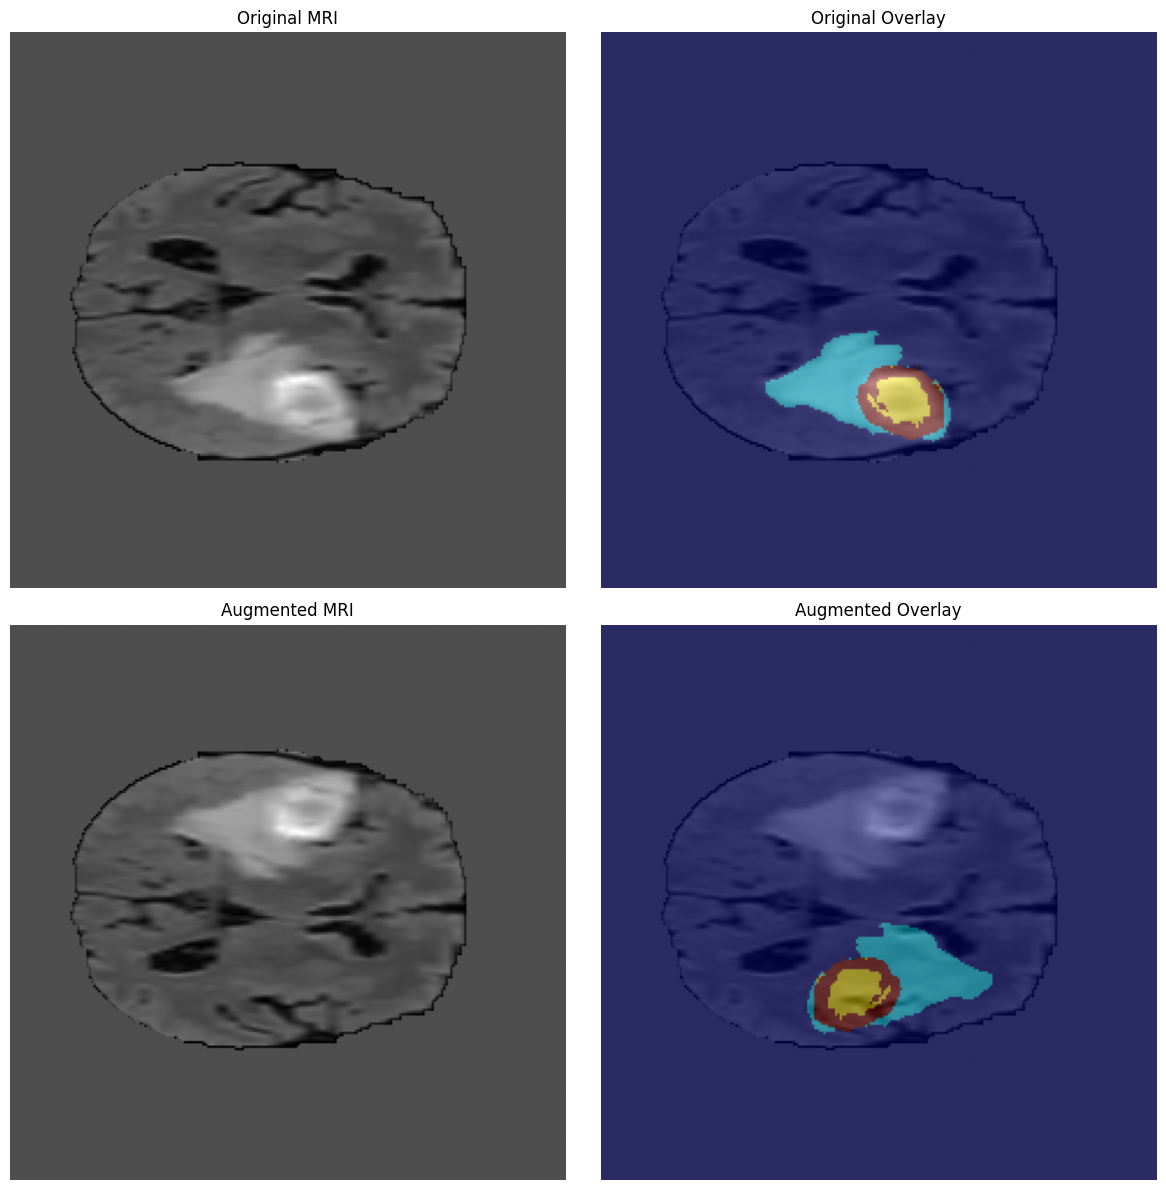

In [29]:
import importlib

import src.visualization
import src.dataloader

importlib.reload(src.visualization)
importlib.reload(src.dataloader)

from src.dataloader import BrainTumourDataset
from src.transforms import get_train_transforms
from src.visualization import compare_samples

original_dataset = BrainTumourDataset()

augmented_dataset = BrainTumourDataset(
    transform=get_train_transforms()
)

original = original_dataset[0]
augmented = augmented_dataset[0]

compare_samples(original, augmented)

In [30]:
dataset = BrainTumourDataset()

sample = dataset[0]

print(sample["patient_id"])

Images : 484
Labels : 484
Dataset verification passed.
BRATS_001


In [31]:
import torch

print(torch.unique(sample["label"]))

tensor([0, 1, 2, 3])


In [32]:
import torch

label = sample["label"]

areas = (label > 0).sum(dim=(0, 1))

best_slice = torch.argmax(areas).item()

print(best_slice)
print(areas[best_slice])

63
tensor(2458)


In [33]:
print(torch.unique(sample["label"]))

tensor([0, 1, 2, 3])


In [40]:
%%writefile src/visualization.py

"""
Visualization utilities for NeuroBrain.
"""

import torch
import matplotlib.pyplot as plt


MODALITIES = {
    0: "FLAIR",
    1: "T1",
    2: "T1ce",
    3: "T2",
}


def compare_samples(
    original,
    augmented,
    modality=0,
    slice_index=None,
):
    """
    Compare original and augmented MRI with segmentation overlay.

    Parameters
    ----------
    original : dict
        Original sample.

    augmented : dict
        Augmented sample.

    modality : int
        MRI modality:
        0 = FLAIR
        1 = T1
        2 = T1ce
        3 = T2

    slice_index : int or None
        Slice to visualize.
        If None, automatically selects the slice
        with the largest tumour area.
    """
    # Automatically choose best tumour slice

    if slice_index is None:

        label = original["label"]

        tumour_area = (label > 0).sum(dim=(0, 1))

        slice_index = torch.argmax(tumour_area).item()

    modality_name = MODALITIES.get(modality, f"Channel {modality}")

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(12, 12),
    )

    # Original MRI

    axes[0, 0].imshow(
        original["image"][modality][:, :, slice_index],
        cmap="gray",
    )

    axes[0, 0].set_title(
        f"Original {modality_name}"
    )

    axes[0, 0].axis("off")

    # Original Overlay

    axes[0, 1].imshow(
        original["image"][modality][:, :, slice_index],
        cmap="gray",
    )

    axes[0, 1].imshow(
        original["label"][:, :, slice_index],
        cmap="jet",
        alpha=0.40,
    )

    axes[0, 1].set_title(
        f"Original Overlay ({modality_name})"
    )

    axes[0, 1].axis("off")

    # Augmented MRI

    axes[1, 0].imshow(
        augmented["image"][modality][:, :, slice_index],
        cmap="gray",
    )

    axes[1, 0].set_title(
        f"Augmented {modality_name}"
    )

    axes[1, 0].axis("off")

    # Augmented Overlay

    axes[1, 1].imshow(
        augmented["image"][modality][:, :, slice_index],
        cmap="gray",
    )

    axes[1, 1].imshow(
        augmented["label"][:, :, slice_index],
        cmap="jet",
        alpha=0.40,
    )

    axes[1, 1].set_title(
        f"Augmented Overlay ({modality_name})"
    )

    axes[1, 1].axis("off")

    plt.tight_layout()

    plt.show()

    tumour_voxels = int(
        (original["label"][:, :, slice_index] > 0).sum()
    )


    print(f"Patient          : {original['patient_id']}")
    print(f"MRI Modality     : {modality_name}")
    print(f"Visualized Slice : {slice_index}")
    print(f"Tumour Voxels    : {tumour_voxels}")



Overwriting src/visualization.py


Images : 484
Labels : 484
Dataset verification passed.
Images : 484
Labels : 484
Dataset verification passed.


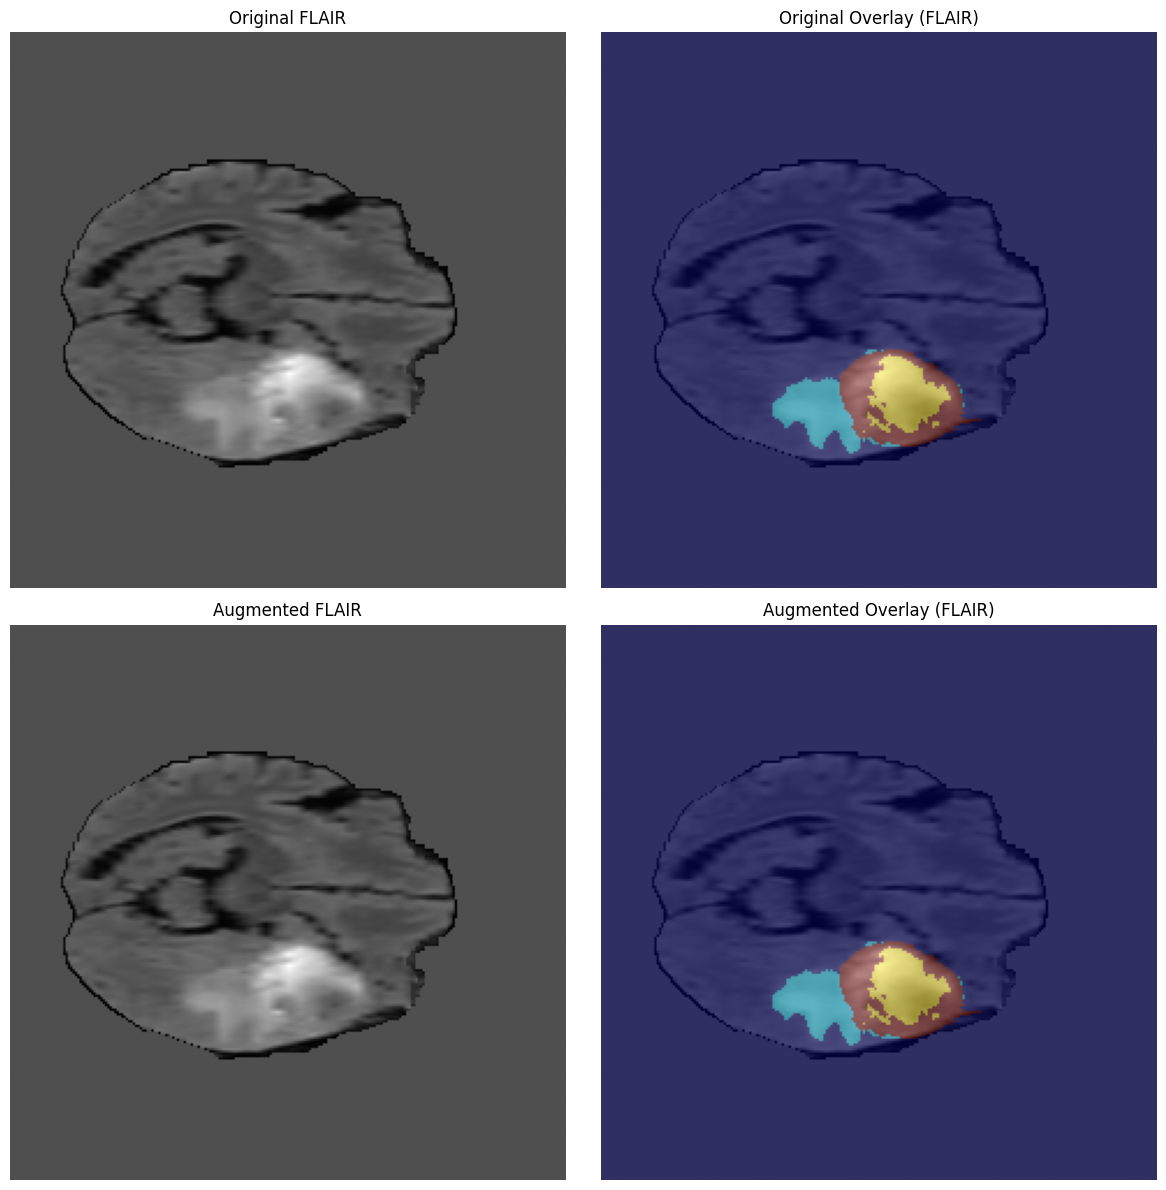

Patient          : BRATS_001
MRI Modality     : FLAIR
Visualized Slice : 63
Tumour Voxels    : 2458


In [41]:
import importlib

import src.visualization
import src.dataloader

importlib.reload(src.visualization)
importlib.reload(src.dataloader)

from src.dataloader import BrainTumourDataset
from src.transforms import get_train_transforms
from src.visualization import compare_samples

original_dataset = BrainTumourDataset()

augmented_dataset = BrainTumourDataset(
    transform=get_train_transforms()
)

original = original_dataset[0]
augmented = augmented_dataset[0]

compare_samples(original, augmented, modality=0)

Images : 484
Labels : 484
Dataset verification passed.
Images : 484
Labels : 484
Dataset verification passed.


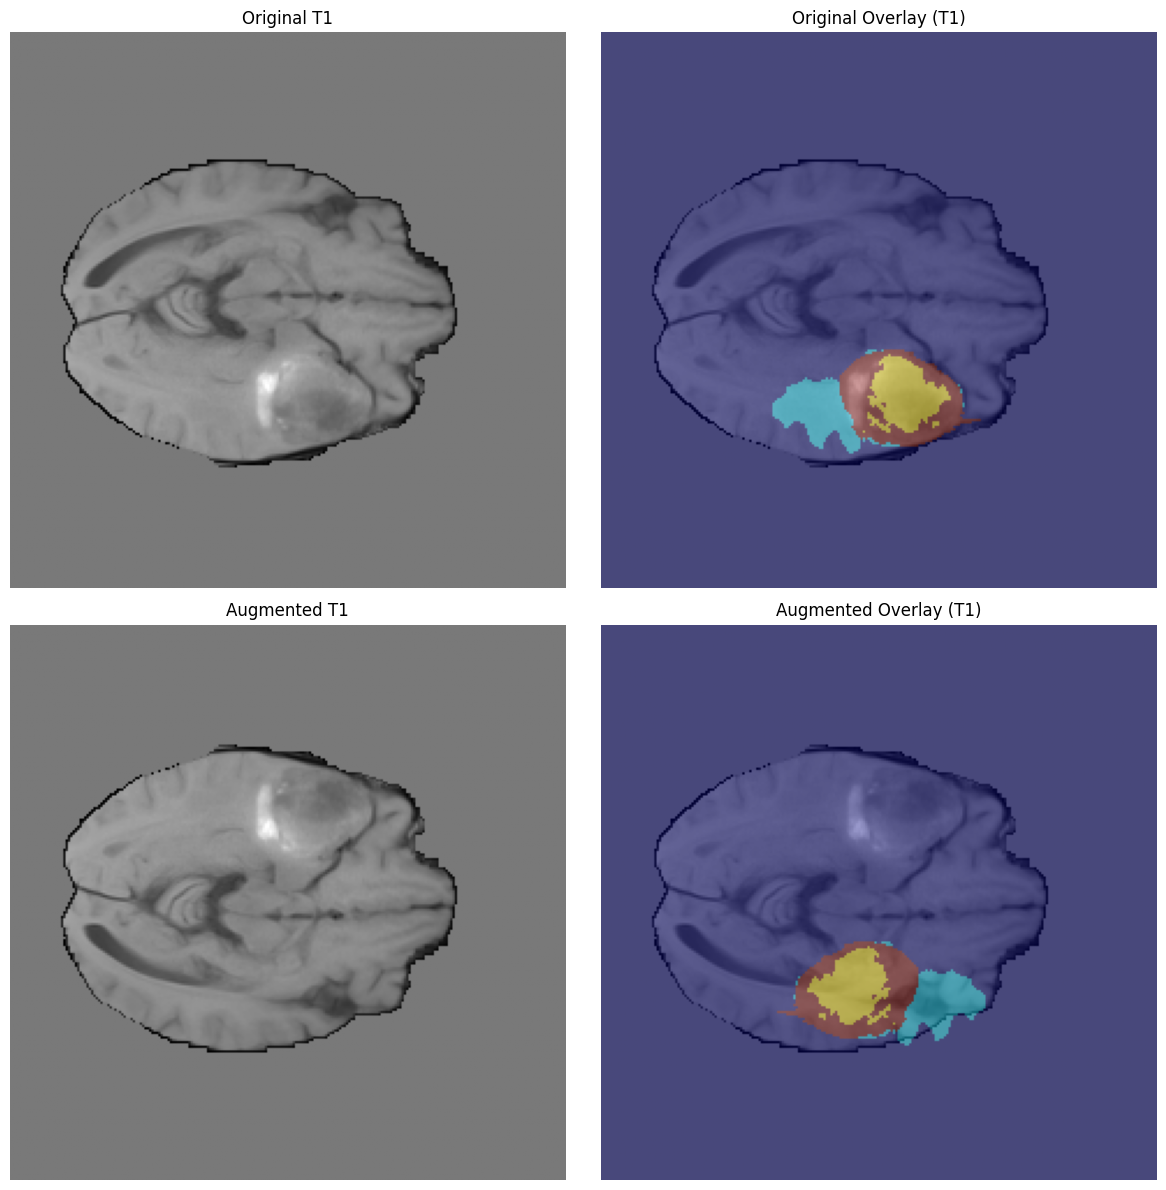

Patient          : BRATS_001
MRI Modality     : T1
Visualized Slice : 63
Tumour Voxels    : 2458


In [47]:
import importlib

import src.visualization
import src.dataloader

importlib.reload(src.visualization)
importlib.reload(src.dataloader)

from src.dataloader import BrainTumourDataset
from src.transforms import get_train_transforms
from src.visualization import compare_samples

original_dataset = BrainTumourDataset()

augmented_dataset = BrainTumourDataset(
    transform=get_train_transforms()
)

original = original_dataset[0]
augmented = augmented_dataset[0]

compare_samples(original, augmented, modality=1)

Images : 484
Labels : 484
Dataset verification passed.
Images : 484
Labels : 484
Dataset verification passed.


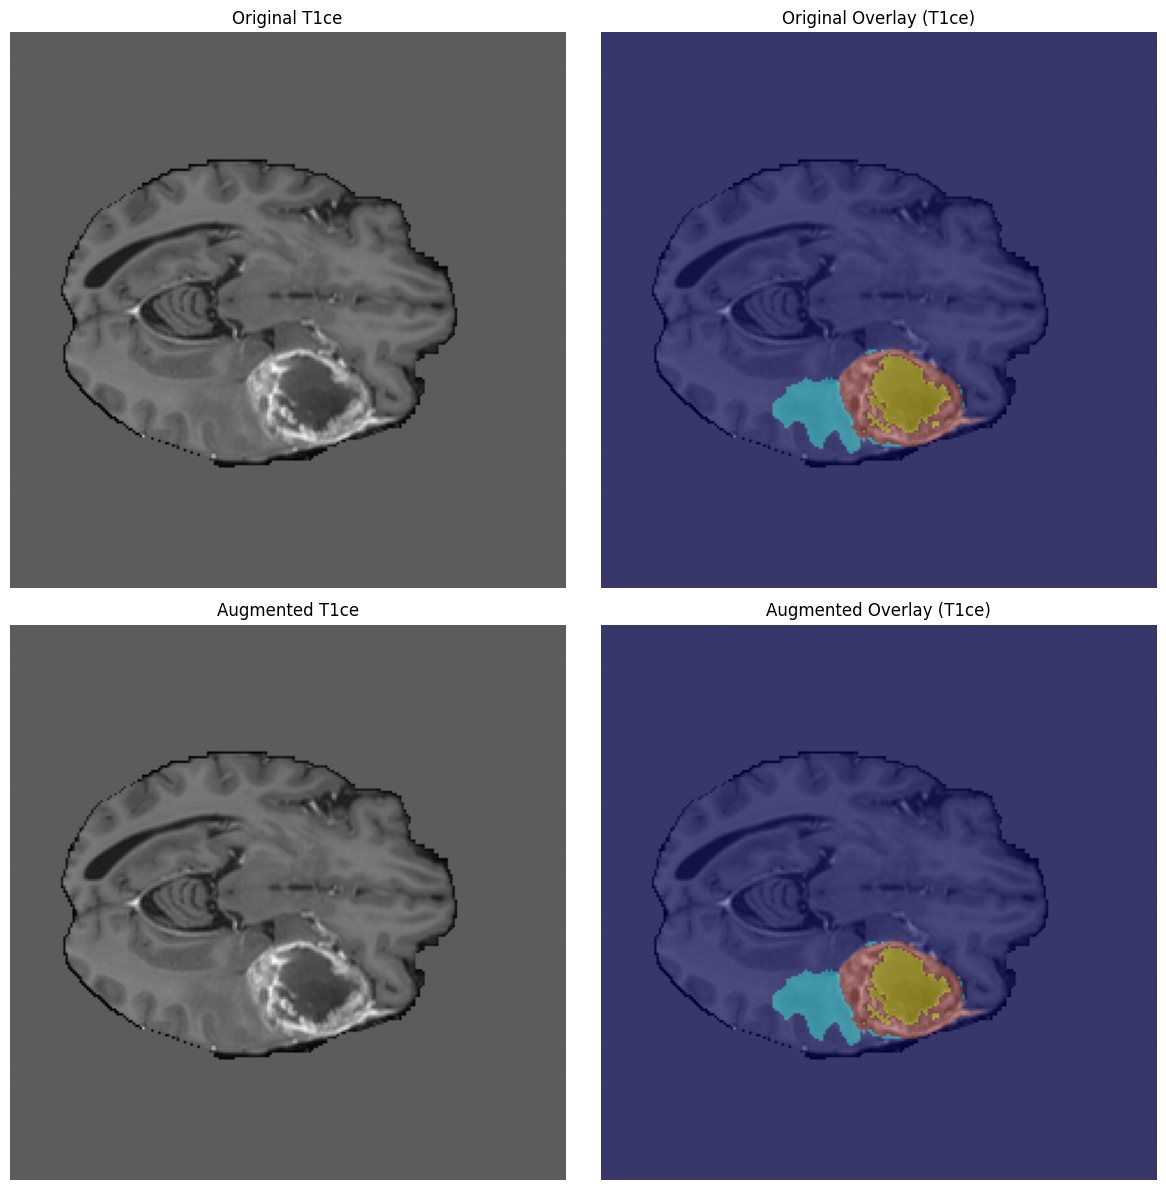

Patient          : BRATS_001
MRI Modality     : T1ce
Visualized Slice : 63
Tumour Voxels    : 2458


In [43]:
import importlib

import src.visualization
import src.dataloader

importlib.reload(src.visualization)
importlib.reload(src.dataloader)

from src.dataloader import BrainTumourDataset
from src.transforms import get_train_transforms
from src.visualization import compare_samples

original_dataset = BrainTumourDataset()

augmented_dataset = BrainTumourDataset(
    transform=get_train_transforms()
)

original = original_dataset[0]
augmented = augmented_dataset[0]

compare_samples(original, augmented, modality=2)

Images : 484
Labels : 484
Dataset verification passed.
Images : 484
Labels : 484
Dataset verification passed.


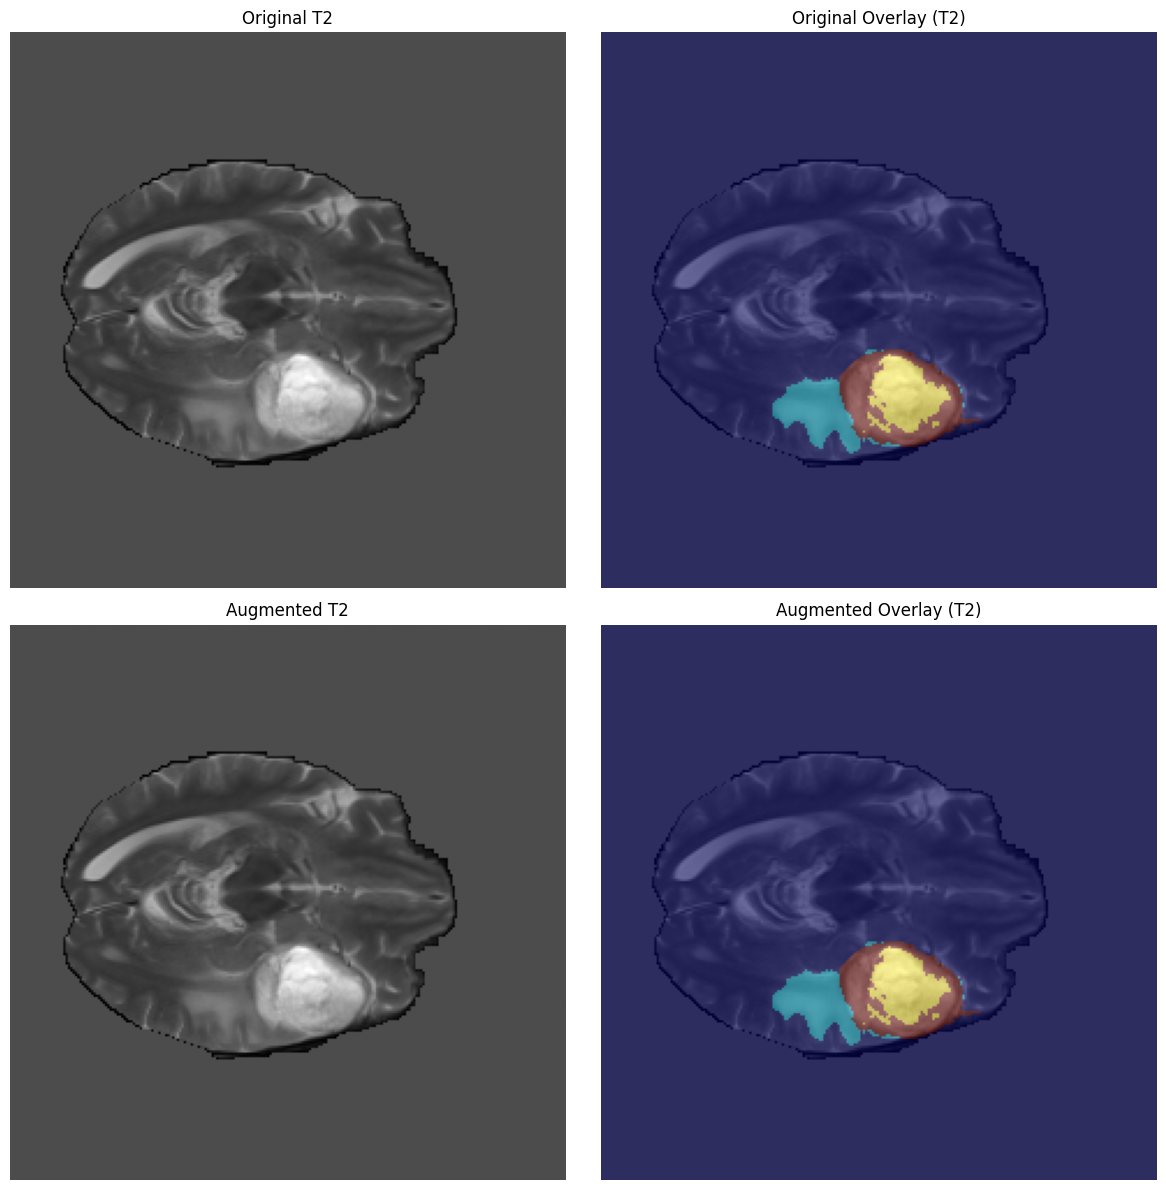

Patient          : BRATS_001
MRI Modality     : T2
Visualized Slice : 63
Tumour Voxels    : 2458


In [44]:
import importlib

import src.visualization
import src.dataloader

importlib.reload(src.visualization)
importlib.reload(src.dataloader)

from src.dataloader import BrainTumourDataset
from src.transforms import get_train_transforms
from src.visualization import compare_samples

original_dataset = BrainTumourDataset()

augmented_dataset = BrainTumourDataset(
    transform=get_train_transforms()
)

original = original_dataset[0]
augmented = augmented_dataset[0]

compare_samples(original, augmented, modality=3)

In [48]:
import torch

original_label = original["label"]
augmented_label = augmented["label"]

original_slice = torch.argmax(
    (original_label > 0).sum(dim=(0, 1))
).item()

augmented_slice = torch.argmax(
    (augmented_label > 0).sum(dim=(0, 1))
).item()

print("Original best slice :", original_slice)
print("Augmented best slice:", augmented_slice)

Original best slice : 63
Augmented best slice: 63


In [49]:
%%writefile src/debug_transforms.py

"""
Deterministic transforms for visualization and debugging.

Unlike the training transforms, these transforms contain
no random augmentations. They are intended only for
verification and visualization.
"""

from monai.transforms import (
    Compose,
    NormalizeIntensityd,
    EnsureTyped,
)


def get_debug_transforms():
    """
    Deterministic transform pipeline.

    Used for:
    - visualization
    - debugging
    - sanity checks

    No random augmentations are applied.
    """

    return Compose(
        [
            NormalizeIntensityd(
                keys="image",
                nonzero=True,
                channel_wise=True,
            ),

            EnsureTyped(
                keys=["image", "label"],
            ),
        ]
    )

Writing src/debug_transforms.py


Images : 484
Labels : 484
Dataset verification passed.
Images : 484
Labels : 484
Dataset verification passed.


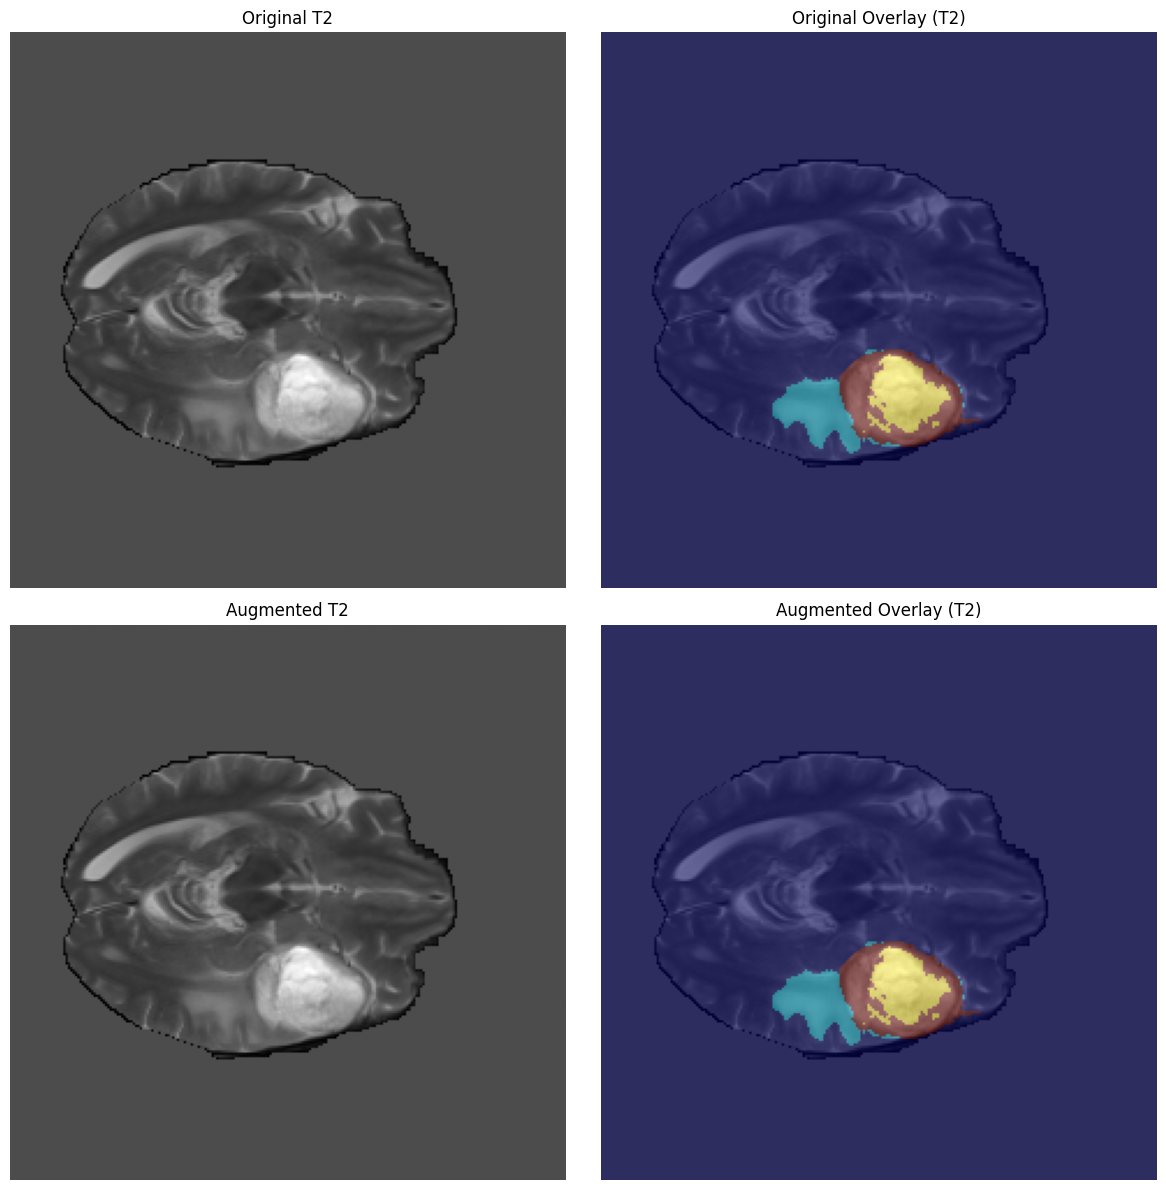

Patient          : BRATS_001
MRI Modality     : T2
Visualized Slice : 63
Tumour Voxels    : 2458


In [56]:
import importlib

import src.visualization
import src.dataloader

importlib.reload(src.visualization)
importlib.reload(src.dataloader)

from src.dataloader import BrainTumourDataset
from src.debug_transforms import get_debug_transforms
from src.visualization import compare_samples

original_dataset = BrainTumourDataset()

debug_dataset = BrainTumourDataset(
    transform=get_debug_transforms()
)

original = original_dataset[0]
debug = debug_dataset[0]

compare_samples(original, debug, modality=3)

In [59]:
!git config --global user.name Shashi
!git config --global user.email 173938981+ethicalcod@users.noreply.github.com

In [60]:
!git add .
!git commit -m "Complete data pipeline with MONAI transforms and debugging utilities"


[main 91afe36] Complete data pipeline with MONAI transforms and debugging utilities
 4 files changed, 209 insertions(+), 15 deletions(-)
 create mode 100644 src/debug_transforms.py
 create mode 100644 src/visualization.py


In [62]:
!git push origin main

Enumerating objects: 11, done.
Counting objects: 100% (11/11), done.
Delta compression using up to 2 threads
Compressing objects: 100% (7/7), done.
Writing objects: 100% (7/7), 1.85 KiB | 1.85 MiB/s, done.
Total 7 (delta 4), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (4/4), completed with 3 local objects.
To https://github.com/ethicalcod/neuroBrain.git
   31e0c21..91afe36  main -> main
